# Lab 3 — Rings, negacyclic multiplication, and modules by hand

**Maths for Post-Quantum Cryptography**, Chapter 3: *Polynomial Rings*

---

Three short pieces, none needing anything beyond what Lab 2 already used.
Negacyclic multiplication and module arithmetic are both written directly
from the formulas in the chapter — no polynomial library, no NTT (that is
Chapter 4's job).

**Part A — negacyclic multiplication, two ways.** Implement Derivation 3.1's
formula $h_k = c_k - c_{k+n}$ directly, and separately as full polynomial
multiplication followed by term-by-term reduction. Confirm they agree, and
confirm the special case "multiply by $x^k$" is exactly a rotate-and-negate
of the coefficient array.

**Part B — does a primitive $2n$-th root exist?** Check $q \equiv 1 \pmod{2n}$
for both standards' moduli, search for a primitive $2n$-th root where the
check says one exists, and confirm the search fails where it does not.

**Part C — a module, by hand.** Build a $k\times k$ matrix and a length-$k$
vector of random $R_q$ elements for each of ML-KEM's three ranks, compute the
matrix-vector product, and check the cost scales as the chapter predicts.

### Requirements

```
python >= 3.9
numpy
matplotlib
```

Nothing else — same as Lab 2, and for the same reason: every algorithm here
is written from scratch so the cost and structure derived in the chapter are
visible in the code, not hidden inside a library call. Install with
`pip install numpy matplotlib`.

### How to use this notebook

Run it top to bottom once. Then look at **Your turn** near the end, which
corresponds to Exercise 3.10. Worked solutions for the pencil-and-paper
exercises (3.1–3.6, 3.11, 3.12) are in Appendix C of the book.

Every section ends with `assert` statements, and the final cell is a single
`_selftest()` that repeats all of them. CI runs this notebook on every
commit; if an assertion fires on your machine, that is a bug in the lab, not
in your understanding — please open an issue.

In [1]:
from __future__ import annotations

import random
import time
from math import gcd

import numpy as np
import matplotlib.pyplot as plt

# Same print-safe, black-and-white styling as Labs 1 and 2.
plt.rcParams.update({
    "figure.figsize": (7.5, 3.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.prop_cycle": plt.cycler(color=["0.15", "0.45", "0.65"]),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

random.seed(0)
print(f"numpy {np.__version__}")

numpy 2.4.4


---

## Part A — negacyclic multiplication, two ways

Two implementations of the same operation from §3.2:

* **`negacyclic_mul_formula`** implements Derivation 3.1's closed form
  directly: $h_k = c_k - c_{k+n}$, where $c_k = \sum_{i+j=k} f_i g_j$.
* **`negacyclic_mul_reduce`** implements the same operation the "obvious"
  way — multiply the two polynomials out in full, then reduce term by term
  using $x^{n+r} \equiv -x^r$, exactly as the worked example in §3.2 did by
  hand for $f(x)\cdot x^3$.

They compute the same ring, so they had better agree on every input.

In [2]:
def negacyclic_mul_formula(f: list[int], g: list[int], q: int) -> list[int]:
    """Negacyclic product h = f*g in Z_q[x]/(x^n+1), via Derivation 3.1:
    h_k = c_k - c_{k+n}, where c_k = sum_{i+j=k} f_i g_j."""
    n = len(f)
    assert len(g) == n
    c = [0] * (2 * n - 1)
    for i in range(n):
        if f[i] == 0:
            continue
        for j in range(n):
            c[i + j] += f[i] * g[j]
    h = [0] * n
    for k in range(n):
        ck_plus_n = c[k + n] if k + n < len(c) else 0
        h[k] = (c[k] - ck_plus_n) % q
    return h


def negacyclic_mul_reduce(f: list[int], g: list[int], q: int) -> list[int]:
    """Same product, computed the 'obvious' way: full polynomial multiply,
    then reduce term by term using x^(n+r) = -x^r (the §3.2 worked-example
    method, not the closed-form shortcut)."""
    n = len(f)
    assert len(g) == n
    prod = [0] * (2 * n - 1)
    for i in range(n):
        if f[i] == 0:
            continue
        for j in range(n):
            prod[i + j] += f[i] * g[j]
    h = [0] * n
    for k, coeff in enumerate(prod):
        if coeff == 0:
            continue
        if k < n:
            h[k] += coeff
        else:
            h[k - n] -= coeff          # x^(n+r) = -x^r
    return [c % q for c in h]


def random_ring_element(n: int, q: int) -> list[int]:
    return [random.randrange(q) for _ in range(n)]


# Agreement check, small n first (easy to debug by eye if this ever fails).
for n, q in [(4, 17), (8, 97)]:
    for _ in range(50):
        f, g = random_ring_element(n, q), random_ring_element(n, q)
        assert negacyclic_mul_formula(f, g, q) == negacyclic_mul_reduce(f, g, q)
print("small-case agreement OK (n=4,q=17 and n=8,q=97)")

# Now the standards' actual n and both moduli.
N = 256
for q, name in [(3329, "ML-KEM"), (8380417, "ML-DSA")]:
    for _ in range(200):
        f, g = random_ring_element(N, q), random_ring_element(N, q)
        assert negacyclic_mul_formula(f, g, q) == negacyclic_mul_reduce(f, g, q)
    print(f"n=256, q={q} ({name}): 200 random pairs agree")

small-case agreement OK (n=4,q=17 and n=8,q=97)


n=256, q=3329 (ML-KEM): 200 random pairs agree


n=256, q=8380417 (ML-DSA): 200 random pairs agree


### The rotate-and-negate special case

§3.2's worked example showed $f(x)\cdot x^3$ by hand for $n=4$. Multiplying
by $x^k$ in general should be exactly a $k$-step rotate-and-negate of the
coefficient array — check it programmatically for every shift $k$, not just
the one worked by hand in the book.

In [3]:
def rotate_negate(f: list[int], k: int, q: int) -> list[int]:
    """Reference implementation of 'multiply by x^k' as a direct rotation:
    each rotate-by-one step moves the top coefficient to the bottom and
    negates it (Exercise 3.4)."""
    h = list(f)
    n = len(f)
    for _ in range(k):
        top = h[-1]
        h = [(-top) % q] + h[:-1]
    return h


n, q = 4, 17
f = [1, 2, 3, 4]
for k in range(0, 9):                        # a couple of full wraps
    x_to_k = [0] * n
    x_to_k[k % n] = (1 if (k // n) % 2 == 0 else -1) % q   # x^k reduced mod x^n+1
    via_formula = negacyclic_mul_formula(f, x_to_k, q)
    via_rotation = rotate_negate(f, k, q)
    assert via_formula == via_rotation, (k, via_formula, via_rotation)
print("multiply-by-x^k matches rotate-and-negate for k = 0..8, confirming the "
      "worked example in §3.2 generalises")

multiply-by-x^k matches rotate-and-negate for k = 0..8, confirming the worked example in §3.2 generalises


---

## Part B — does a primitive $2n$-th root exist?

`order`, `factorize` and `smallest_primitive_root` are exactly Lab 2's
versions (repeated here so this notebook is self-contained). What is new is
searching specifically for an element of order $2n$, per Derivation 3.3.

In [4]:
def factorize(m: int) -> dict[int, int]:
    """Prime factorization of m by trial division."""
    factors: dict[int, int] = {}
    d = 2
    while d * d <= m:
        while m % d == 0:
            factors[d] = factors.get(d, 0) + 1
            m //= d
        d += 1 if d == 2 else 2
    if m > 1:
        factors[m] = factors.get(m, 0) + 1
    return factors


def order(a: int, q: int, factors_of_qm1: dict[int, int] | None = None) -> int:
    """Multiplicative order of a modulo prime q (Lab 2, Chapter 2 Definition 2.3)."""
    if gcd(a, q) != 1:
        raise ValueError(f"{a} is not a unit modulo {q}")
    if factors_of_qm1 is None:
        factors_of_qm1 = factorize(q - 1)
    m = q - 1
    for p in factors_of_qm1:
        while m % p == 0 and pow(a, m // p, q) == 1:
            m //= p
    return m


def smallest_primitive_root(q: int) -> int:
    factors_of_qm1 = factorize(q - 1)
    g = 2
    while not all(pow(g, (q - 1) // p, q) != 1 for p in factors_of_qm1):
        g += 1
    return g


def has_nth_root_of_unity(n: int, q: int) -> bool:
    """True iff Z_q^x contains a primitive n-th root of unity, i.e. n | q - 1."""
    return (q - 1) % n == 0


def element_of_order_2n(n: int, q: int) -> int:
    """An element psi of Z_q^x with order exactly 2n (Derivation 3.3), built
    from a primitive root g. Raises if 2n does not divide q - 1."""
    two_n = 2 * n
    if (q - 1) % two_n != 0:
        raise ValueError(f"2n = {two_n} does not divide q - 1 = {q - 1}; "
                          f"no primitive 2n-th root of unity exists mod {q}")
    g = smallest_primitive_root(q)
    return pow(g, (q - 1) // two_n, q)


# Sanity check against the worked example: q=17, n=4, 2n=8.
assert has_nth_root_of_unity(8, 17)
psi17 = element_of_order_2n(4, 17)
assert order(psi17, 17) == 8
odd_powers = sorted(pow(psi17, 2 * i + 1, 17) for i in range(4))
brute_force_roots = sorted(a for a in range(17) if (pow(a, 4, 17) + 1) % 17 == 0)
assert odd_powers == brute_force_roots == [2, 8, 9, 15]
print(f"q=17, n=4: psi = {psi17}, odd powers = {odd_powers} "
      f"-- matches the book's worked example exactly")

q=17, n=4: psi = 9, odd powers = [2, 8, 9, 15] -- matches the book's worked example exactly


In [5]:
N = 256
TWO_N = 2 * N
print(f"n = {N}, 2n = {TWO_N}\n")

for q, name in [(3329, "ML-KEM"), (8380417, "ML-DSA")]:
    exists = has_nth_root_of_unity(TWO_N, q)
    print(f"q = {q:>8} ({name:>7}): q-1 = {q-1:>9}, 2n | q-1 ? {exists}")
    if exists:
        psi = element_of_order_2n(N, q)
        assert order(psi, q) == TWO_N
        print(f"    -> found psi with order exactly {TWO_N}: psi = {psi}")
    else:
        try:
            element_of_order_2n(N, q)
            raise AssertionError("expected a ValueError, got a root instead")
        except ValueError as e:
            print(f"    -> search correctly refuses: {e}")

assert not has_nth_root_of_unity(TWO_N, 3329)          # Kyber: no 512th root
assert has_nth_root_of_unity(TWO_N, 8380417)           # Dilithium: has one

n = 256, 2n = 512

q =     3329 ( ML-KEM): q-1 =      3328, 2n | q-1 ? False
    -> search correctly refuses: 2n = 512 does not divide q - 1 = 3328; no primitive 2n-th root of unity exists mod 3329
q =  8380417 ( ML-DSA): q-1 =   8380416, 2n | q-1 ? True
    -> found psi with order exactly 512: psi = 1921994


This is exactly Chapter 2's divisibility table, read through the lens of
§3.4: ML-DSA's modulus supports a full split of $x^{256}+1$ into 256 linear
factors; ML-KEM's does not, and Chapter 4 is where that shortfall turns into
an actual (still exact, still correct) transform that bottoms out one level
early.

---

## Part C — a module, by hand

A $k\times k$ matrix $A$ over $R_q$ and a length-$k$ vector $s$ over $R_q$,
built for each of ML-KEM's three ranks. Computing $As$ needs $k^2$
negacyclic products (Part A) and $k$ length-$k$ sums in $\Z_q$ — the
$\bigO(k^2 n^2)$ prediction from the end of §3.5, with $l=k$ since ML-KEM's
matrix is square.

k = 2: computed As (2x2 matrix times length-2 vector) in 16.3 ms
k = 3: computed As (3x3 matrix times length-3 vector) in 38.0 ms
k = 4: computed As (4x4 matrix times length-4 vector) in 65.7 ms


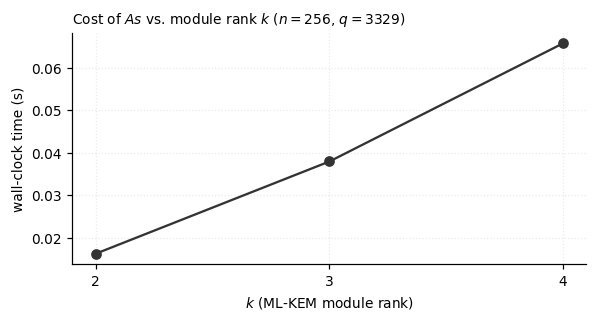

timings[4] / timings[2] = 4.04  (O(k^2) predicts close to 4)


In [6]:
def random_matrix(k: int, l: int, n: int, q: int):
    return [[random_ring_element(n, q) for _ in range(l)] for _ in range(k)]


def random_vector(l: int, n: int, q: int):
    return [random_ring_element(n, q) for _ in range(l)]


def add_ring(f: list[int], g: list[int], q: int) -> list[int]:
    return [(a + b) % q for a, b in zip(f, g)]


def module_matvec(A, s, n: int, q: int):
    """(As)_i = sum_j A_ij s_j in R_q, for A a k x l matrix and s a length-l
    vector of R_q elements (§3.5)."""
    k = len(A)
    l = len(s)
    result = []
    for i in range(k):
        acc = [0] * n
        for j in range(l):
            acc = add_ring(acc, negacyclic_mul_formula(A[i][j], s[j], q), q)
        result.append(acc)
    return result


N, Q = 256, 3329
timings = {}
for k in (2, 3, 4):
    A = random_matrix(k, k, N, Q)
    s = random_vector(k, N, Q)
    t0 = time.perf_counter()
    As = module_matvec(A, s, N, Q)
    timings[k] = time.perf_counter() - t0
    assert len(As) == k and all(len(row) == N for row in As)
    print(f"k = {k}: computed As ({k}x{k} matrix times length-{k} vector) "
          f"in {timings[k]*1000:.1f} ms")

fig, ax = plt.subplots(figsize=(5.5, 3.0))
ks = sorted(timings)
ax.plot(ks, [timings[k] for k in ks], "o-", color="0.2")
ax.set_xlabel("$k$ (ML-KEM module rank)")
ax.set_ylabel("wall-clock time (s)")
ax.set_xticks(ks)
ax.set_title("Cost of $As$ vs. module rank $k$ ($n=256$, $q=3329$)",
             fontsize=9, loc="left")
plt.tight_layout(); plt.show()

# The O(k^2 n^2) prediction: going from k=2 to k=4 should cost roughly
# (4/2)^2 = 4x as much work, not 2x -- check the measured ratio is in that
# ballpark rather than scaling linearly.
ratio = timings[4] / timings[2]
print(f"timings[4] / timings[2] = {ratio:.2f}  (O(k^2) predicts close to 4)")
assert ratio > 2.0, "cost should grow faster than linearly in k"

The ratio will not land exactly on 4 — Python overhead and cache effects
blur small timings — but it should sit well clear of 2, which is what a
linear-in-$k$ (rather than quadratic) cost would predict. §3.5 derived the
$k^2$ figure from counting negacyclic products directly; this cell is the
same argument, measured rather than counted.

---

## Your turn — Exercise 3.10: the rectangular case

Part C above used ML-KEM's square matrices ($k=l$). ML-DSA's matrix is
$k\times l$ with $k \ne l$ (Table 3.1). Extend Part C to ML-DSA's three
$(k,l)$ pairs, at $q = 8380417$, and confirm the cost scales as
$\bigO(kl\,n^2)$ rather than $\bigO(k^2 n^2)$ — the general module
matrix-vector product from §3.5, of which Part C's square case is a special
instance.

In [7]:
# --- Exercise 3.10 --------------------------------------------------------
Q_DILITHIUM = 8380417
ML_DSA_PARAMS = [(4, 4), (6, 5), (8, 7)]   # (k, l) for ML-DSA-44/65/87

# for k, l in ML_DSA_PARAMS:
#     A = random_matrix(k, l, N, Q_DILITHIUM)
#     s = random_vector(l, N, Q_DILITHIUM)
#     ... time module_matvec(A, s, N, Q_DILITHIUM) as above ...
#
# Then compare the measured cost across the three pairs against kl (not k^2):
# ML-DSA-44 has kl=16, ML-DSA-65 has kl=30, ML-DSA-87 has kl=56 -- roughly a
# 3.5x spread from smallest to largest, not the 4x you'd get from k alone.

---

## What to take away

Every formula in this lab was already fully determined by Chapter 3's
derivations before a single cell ran — Part A's two implementations had no
freedom to disagree, and Part B's search either finds what Derivation 3.3
promises or correctly refuses, with no middle ground. That is worth noticing:
this chapter did not describe an algorithm and then ask you to trust it, it
derived exactly what the algorithm computes and why, and the notebook exists
to confirm the derivation rather than to introduce anything new.

Chapter 4 picks up exactly where §3.4 left off: the same divisibility check
run here, turned into an $\bigO(n\log n)$ multiplication algorithm.

---

*Standards status referenced in this lab was verified on 16 August 2026. Live
status: https://mathsforeverything.com/pqc/standards*

In [8]:
# --------------------------------------------------------------------------
# CI smoke test. Runs on every commit; keeps this notebook honest against
# library updates. If this cell fails, the lab is broken -- please open an issue.
# --------------------------------------------------------------------------
def _selftest():
    for n, q in [(4, 17), (8, 97)]:
        for _ in range(20):
            f, g = random_ring_element(n, q), random_ring_element(n, q)
            assert negacyclic_mul_formula(f, g, q) == negacyclic_mul_reduce(f, g, q)

    n, q = 256, 3329
    for _ in range(20):
        f, g = random_ring_element(n, q), random_ring_element(n, q)
        assert negacyclic_mul_formula(f, g, q) == negacyclic_mul_reduce(f, g, q)

    f = [1, 2, 3, 4]
    for k in range(0, 5):
        x_to_k = [0] * 4
        x_to_k[k % 4] = (1 if (k // 4) % 2 == 0 else -1) % 17
        assert negacyclic_mul_formula(f, x_to_k, 17) == rotate_negate(f, k, 17)

    assert has_nth_root_of_unity(8, 17)
    psi17_ = element_of_order_2n(4, 17)
    assert order(psi17_, 17) == 8
    assert sorted(pow(psi17_, 2*i+1, 17) for i in range(4)) == [2, 8, 9, 15]

    assert not has_nth_root_of_unity(512, 3329)
    assert has_nth_root_of_unity(512, 8380417)
    psi_dsa = element_of_order_2n(256, 8380417)
    assert order(psi_dsa, 8380417) == 512
    try:
        element_of_order_2n(256, 3329)
        raise AssertionError("expected ValueError")
    except ValueError:
        pass

    for k in (2, 3, 4):
        A = random_matrix(k, k, 256, 3329)
        s = random_vector(k, 256, 3329)
        As = module_matvec(A, s, 256, 3329)
        assert len(As) == k and all(len(row) == 256 for row in As)

    return "all checks passed"

print(_selftest())

all checks passed
